In [2]:
!pip3 install spicelib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Simulating...

✅ ¡Simulación terminada!
📄 RAW: results_ac/preamp_ac_sweep_2d_1.raw
📄 LOG: results_ac/preamp_ac_sweep_2d_1.log

--- 🔍 Resumen del Archivo LOG ---
  -> Warning: Multiple definitions of model "2scr375p" Type: BJT
  -> Warning: Multiple definitions of model "bc857b" Type: BJT
  -> Warning: Multiple definitions of model "bc847c" Type: BJT
  -> Warning: Multiple definitions of model "bc847b" Type: BJT
  -> Total elapsed time: 0.386 seconds.
----------------------------------

📊 Extrayendo datos y generando gráfico...


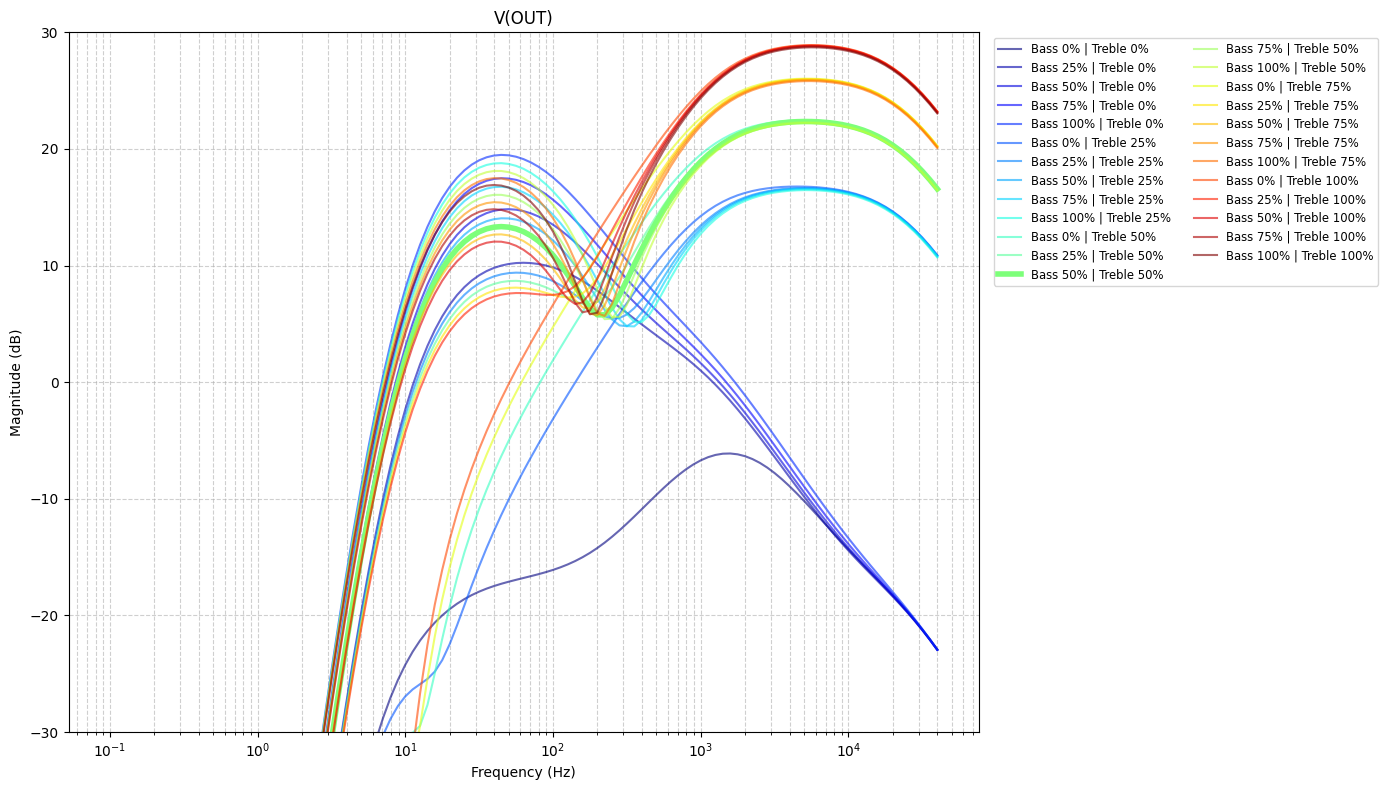

In [55]:
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

results_dir = './results_ac'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir) # Borra la carpeta y todo su contenido
os.makedirs(results_dir)       # La vuelve a crear vacía y limpia

# Definir la ruta del ejecutable de LTspice en macOS
class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

#netlist = SpiceEditor("../schematics/redcircuits_design/red_circuits_design.net")
netlist = SpiceEditor("../schematics/iteration1/redesign_15v.net")
netlist.remove_component('V1')

# spicelib seems to be buggy! empty lines are problematic
netlist.netlist = [x for x in netlist.netlist if x.strip()]


netlist.add_instruction("V_AC IN 0 AC 1")
netlist.add_instruction(".ac dec 20 0.1 40k")

# I need to add this from time to time
netlist.netlist = [x for x in netlist.netlist if x.strip()] 

netlist.add_instruction(".step param bass list 0 0.25 0.5 0.75 1")
netlist.add_instruction(".step param treble list 0 0.25 0.5 0.75 1")


netlist.set_parameters(vol=1.0, brightness=0.0, drive=0.0)  # no need to set in_amplitude or in_freq, we are in .ac mode


netlist.save_netlist("preamp_ac_sweep_2d.net")
print("Simulating...")

runner = SimRunner(simulator=MacLTspice, output_folder='./results_ac')
runner.run("preamp_ac_sweep_2d.net")

# El bucle 'for' actuará como bloqueante natural hasta que LTspice termine
for raw_path, log_path in runner:
    print(f"\n✅ ¡Simulación terminada!")
    print(f"📄 RAW: {raw_path}")
    print(f"📄 LOG: {log_path}")

    # --- EJEMPLO: RECUPERAR INFORMACIÓN DEL LOG ---
    # Leemos el archivo .log como un archivo de texto normal para buscar métricas o errores
    if os.path.exists(log_path):
        print("\n--- 🔍 Resumen del Archivo LOG ---")
        with open(log_path, 'r', encoding='utf-16-le', errors='ignore') as log_file:
            for linea in log_file:
                # Buscamos palabras clave de interés en cada línea
                if "Warning" in linea or "Fatal Error" in linea or "Total elapsed time" in linea:
                    print(f"  -> {linea.strip()}")
        print("----------------------------------\n")

    # --- LECTURA DE DATOS RAW Y PLOTEO ---
    if not os.path.exists(raw_path):
        print(f"❌ Error: El archivo {raw_path} no se generó correctamente.")
        continue

    print("📊 Extrayendo datos y generando gráfico...")
    raw = RawRead(raw_path)
    pasos_indices = raw.get_steps() 
    
    colores = plt.cm.jet(np.linspace(0, 1, len(pasos_indices)))
    plt.figure(figsize=(14, 8))
    
    for i in pasos_indices:
        # EXTRACCIÓN MANUAL DE FRECUENCIA PARA ESQUIVAR EL BUG DE get_axis()
        try:
            freq_complex = raw.get_trace('frequency').get_wave(i)
        except KeyError:
            freq_complex = raw.get_trace('freq').get_wave(i)
            
        freq = np.real(freq_complex)
        
        # Petición del nodo de salida
        try:
            v_out_complex = raw.get_trace('V(OUT)').get_wave(i)
        except KeyError:
            v_out_complex = raw.get_trace('V(out)').get_wave(i)
            
        # Calcular Magnitud en dB
        v_out_mag = np.abs(v_out_complex)
        v_out_db = 20 * np.log10(v_out_mag + 1e-12) 
        
        # Leer parámetros para la leyenda
        step_info = raw.steps[i]
        b_val = step_info.get('bass', 0)
        t_val = step_info.get('treble', 0)
        
        b_pct = int(b_val * 100)
        t_pct = int(t_val * 100)
        
        # Estilos: destacar la curva central (50/50)
        grosor = 4 if (b_pct == 50 and t_pct == 50) else 1.5
        alpha_val = 1.0 if (b_pct == 50 and t_pct == 50) else 0.6
        
        plt.plot(freq, v_out_db, label=f'Bass {b_pct}% | Treble {t_pct}%', 
                 color=colores[i], linewidth=grosor, alpha=alpha_val)

    # Configuración visual del gráfico principal
    plt.title("V(OUT)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.xscale('log') 
    plt.ylim([-30, 30])
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    
    # Leyenda fuera del área de ploteo
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

In [3]:
!ls ../schematics/redcircuits_design/

red_circuits_design.asc


Simulating Noise Performance...

✅ Simulation Finished!
📊 Extracting noise data...


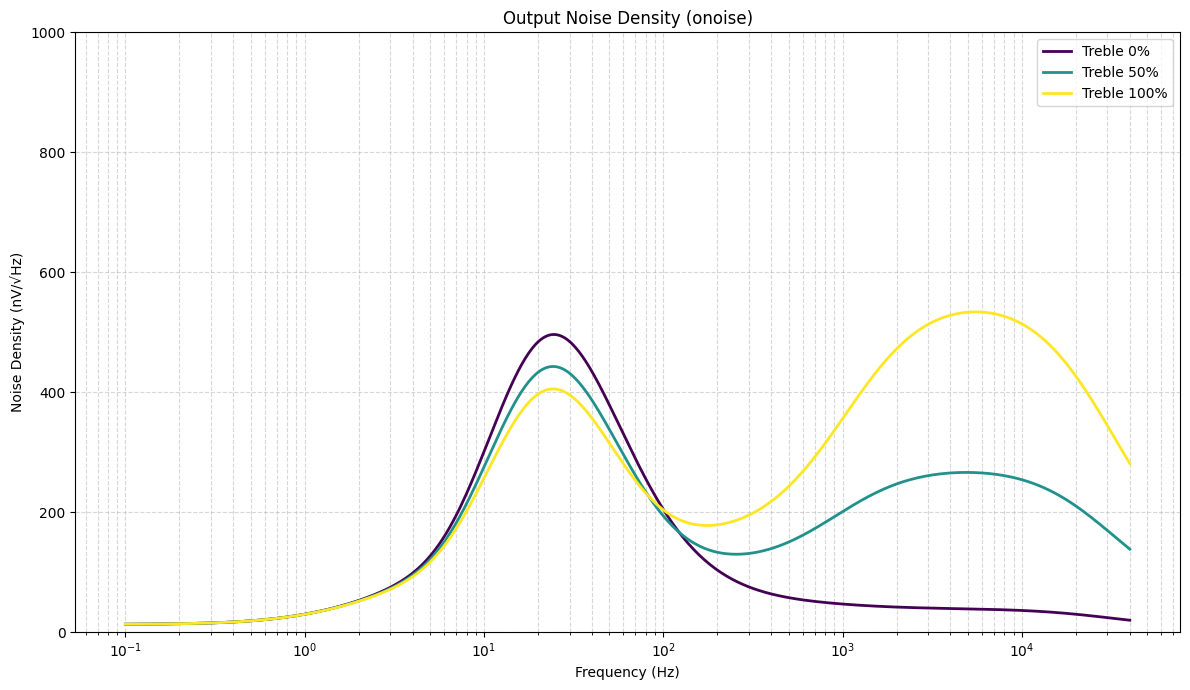

In [54]:
from spicelib import SpiceEditor, SimRunner, RawRead
from spicelib.simulators.ltspice_simulator import LTspice
import matplotlib.pyplot as plt
import numpy as np
import shutil
import os

results_dir = './results_noise'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir) 
os.makedirs(results_dir)

class MacLTspice(LTspice):
    spice_exe = ['/Applications/LTspice.app/Contents/MacOS/LTspice']

# Path to your netlist
netlist = SpiceEditor("../schematics/iteration1/redesign_15v.net")
netlist.remove_component('V1')

# Clean up empty lines
netlist.netlist = [x for x in netlist.netlist if x.strip()]

# NOISE INSTRUCTION: .noise V(OUTPUT_NODE) SOURCE_NAME TYPE POINTS START STOP
# We analyze output noise relative to a 1V AC input at IN
netlist.add_instruction("V_AC IN 0 AC 1") 
netlist.add_instruction(".noise V(OUT) V_AC dec 100 0.1 40k")

# Optional: You can still step parameters to see how Bass/Treble affect noise
netlist.add_instruction(".step param treble list 0 0.5 1")

# Set static parameters
netlist.set_parameters(vol=1.0, drive=0.5, bass=0.5)

netlist.save_netlist("preamp_noise_analysis.net")
print("Simulating Noise Performance...")

runner = SimRunner(simulator=MacLTspice, output_folder='./results_noise')
runner.run("preamp_noise_analysis.net")

for raw_path, log_path in runner:
    print(f"\n✅ Simulation Finished!")
    
    if not os.path.exists(raw_path):
        print(f"❌ Error: {raw_path} not found.")
        continue

    print("📊 Extracting noise data...")
    raw = RawRead(raw_path)
    pasos_indices = raw.get_steps() 
    
    plt.figure(figsize=(12, 7))
    colores = plt.cm.viridis(np.linspace(0, 1, len(pasos_indices)))

    for i in pasos_indices:
            # 1. Get Frequency axis (remains the same)
            try:
                freq_complex = raw.get_trace('frequency').get_wave(i)
            except KeyError:
                freq_complex = raw.get_trace('freq').get_wave(i)
            freq = np.real(freq_complex)
            
            # 2. Get Noise Trace - Updated to look for V(onoise)
            try:
                # Try the formal LTspice name first
                v_noise = raw.get_trace('V(onoise)').get_wave(i)
            except (KeyError, IndexError):
                try:
                    # Fallback to the short name
                    v_noise = raw.get_trace('onoise').get_wave(i)
                except (KeyError, IndexError):
                    print(f"❌ Error: Could not find noise trace in step {i}")
                    continue
                
            # Noise is returned as a complex number (magnitude/phase), 
            # though phase is usually 0 for noise density.
            v_noise_density = np.abs(v_noise)
            
            # Convert to nV/sqrt(Hz) for a readable scale (e.g., 20nV instead of 0.00000002)
            v_noise_nv = v_noise_density * 1e9 
            
            # 3. Handle step info and plotting
            step_info = raw.steps[i]
            t_val = step_info.get('treble', 0.5)
            t_pct = int(t_val * 100)
            
            plt.plot(freq, v_noise_nv, label=f'Treble {t_pct}%', 
                     color=colores[i], linewidth=2)

    # UI Configuration
    plt.title("Output Noise Density (onoise)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Noise Density (nV/√Hz)")
    plt.xscale('log') 
    plt.ylim([0, 1000])
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()